In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.preprocessing import add_features, clean_data, load_data

sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/raw/Churn_Modelling.csv")

In [2]:
df = load_data(DATA_PATH)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum())
print("\nDuplicated rows:", df.duplicated().sum())

Shape: (10000, 14)

Columns:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicated rows: 0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


In [6]:
cleaned_df = clean_data(df)
featured_df = add_features(cleaned_df)

print("Shape after cleaning and feature engineering:", featured_df.shape)
featured_df.head()

Shape after cleaning and feature engineering: (10000, 19)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureAgeRatio,IsSenior,CreditScoreBucket,ProductsPerBalance,IsLowCredit,HighBalance,AgeBucket
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.047619,0,medium,1.000000,0,0,"(30, 45]"
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744677,0.024390,0,medium,0.000012,0,0,"(30, 45]"
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401375,0.190476,0,medium,0.000019,1,1,"(30, 45]"
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,0.025641,0,good,2.000000,0,0,"(30, 45]"
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587055,0.046512,0,excellent,0.000008,0,1,"(30, 45]"


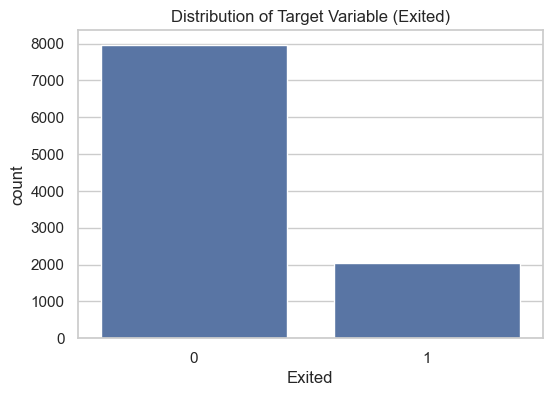

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=featured_df, x="Exited")
plt.title("Distribution of Target Variable (Exited)")
plt.show()

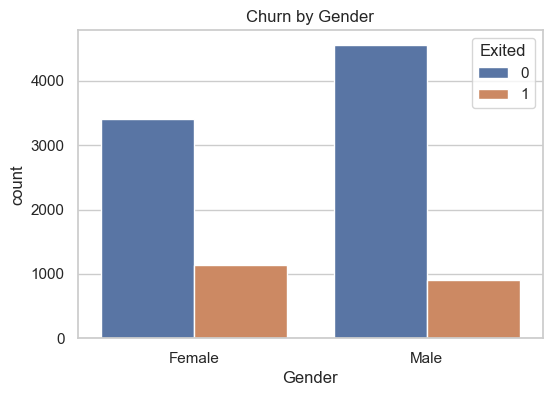

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=featured_df, x="Gender", hue="Exited")
plt.title("Churn by Gender")
plt.show()

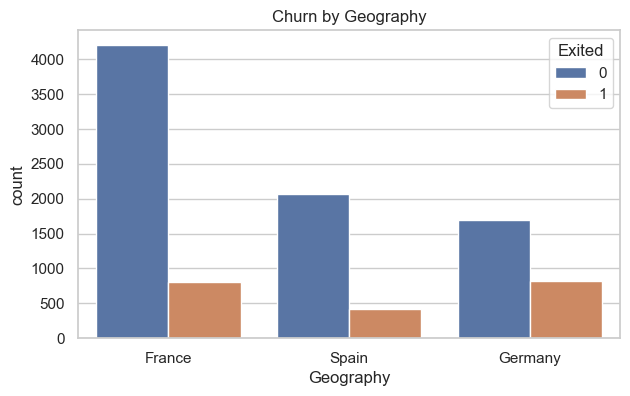

In [9]:
plt.figure(figsize=(7, 4))
sns.countplot(data=featured_df, x="Geography", hue="Exited")
plt.title("Churn by Geography")
plt.show()

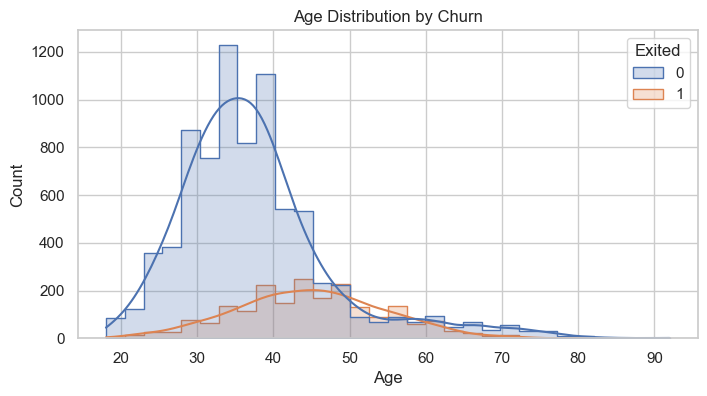

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(data=featured_df, x="Age", hue="Exited", bins=30, kde=True, element="step")
plt.title("Age Distribution by Churn")
plt.show()

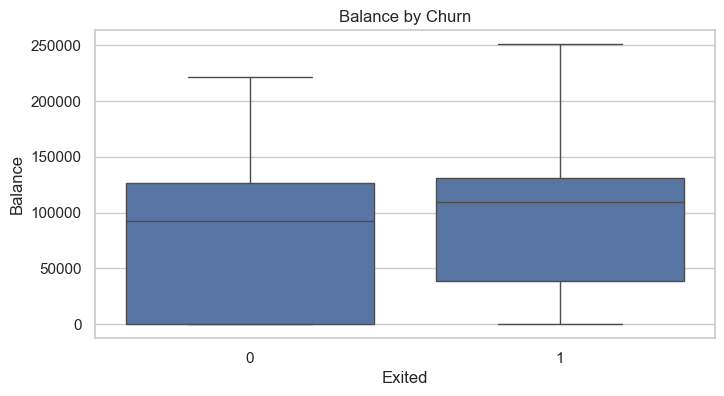

In [11]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=featured_df, x="Exited", y="Balance")
plt.title("Balance by Churn")
plt.show()

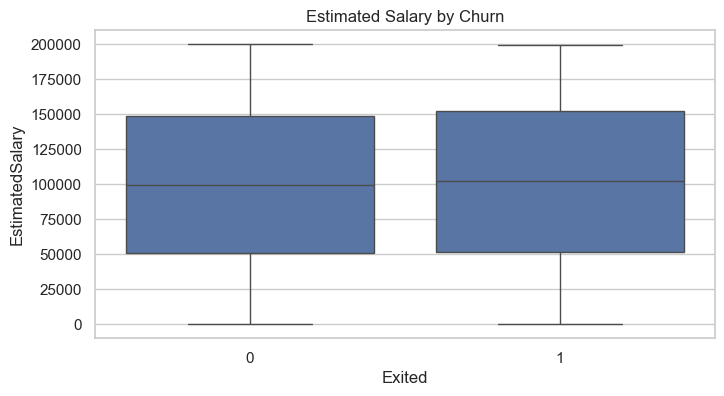

In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=featured_df, x="Exited", y="EstimatedSalary")
plt.title("Estimated Salary by Churn")
plt.show()

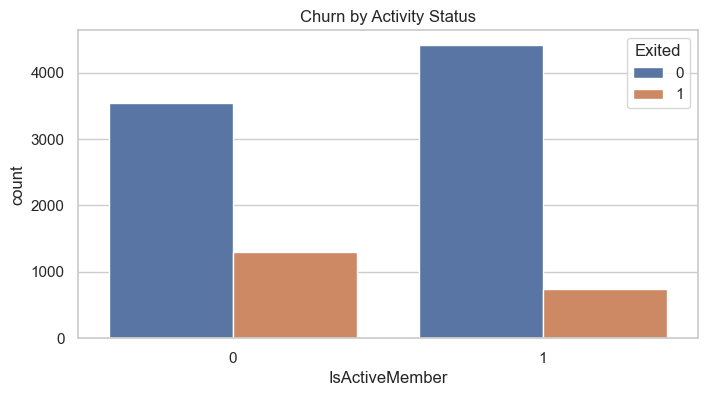

In [13]:
plt.figure(figsize=(8, 4))
sns.countplot(data=featured_df, x="IsActiveMember", hue="Exited")
plt.title("Churn by Activity Status")
plt.show()

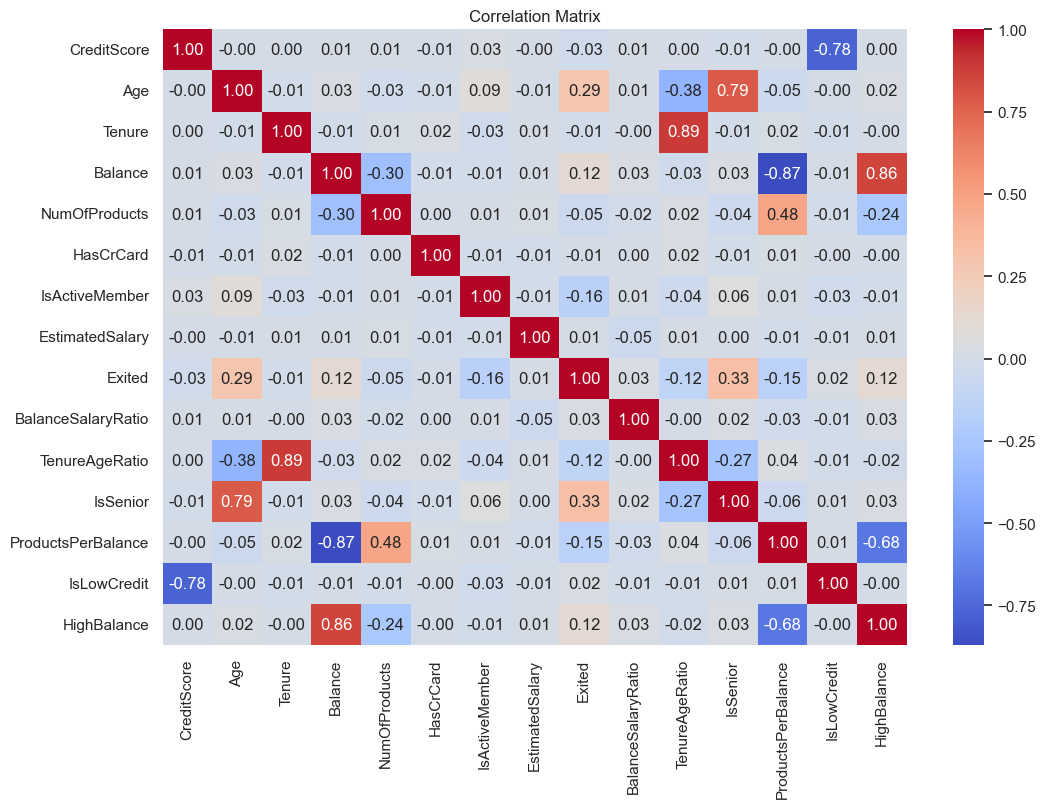

In [14]:
numeric_df = featured_df.select_dtypes(include="number")
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [15]:
featured_df.to_csv("../data/processed/churn_featured.csv", index=False)